In [99]:
import nibabel as nib
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
# helpers from other code
def load_nifti_image(image_path):
    img = nib.load(image_path)
    return img.get_fdata()

def apply_mask(mr_image, mask):
    if mr_image.shape != mask.shape:
        raise ValueError(f"Unmatched Image and mask shape {mr_image.shape} vs {mask.shape}")
    return mr_image * (mask > 0).astype(mr_image.dtype)

def center_pad_single_slice(image):
    h, w = image.shape
    max_size = max(h, w)
    pad_h = (max_size - h) // 2
    pad_w = (max_size - w) // 2
    square_slice = np.zeros((max_size, max_size), dtype=image.dtype)
    square_slice[pad_h:pad_h+h, pad_w:pad_w+w] = image
    return square_slice, (pad_h, pad_w)

def minmax_normalize_numpy(volume, clip_range=(0, 2000)):
    v = volume.astype(np.float32)
    v = v.clip(*clip_range)
    v_min, v_max = np.min(v), np.max(v)
    if v_max > v_min:
        v = (v - v_min) / (v_max - v_min) * 255
    else:
        v = np.zeros_like(v)
    return v.astype(np.uint8)

# your detector methods for body mask
from scipy.ndimage import binary_erosion, binary_dilation
import cv2

def get_mask_biggest_contour(mask_ct):
    for i in range(mask_ct.shape[2]):
        inmask = np.expand_dims(mask_ct[:, :, i].astype(np.uint8), axis=2)
        _, bin_img = cv2.threshold(inmask, 0.5, 1, cv2.THRESH_BINARY)
        cnts, _ = cv2.findContours(np.expand_dims(bin_img, axis=2),
                                   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(cnts) != 0:
            segmented = max(cnts, key=cv2.contourArea)
            bin_img[bin_img > 0] = 0
            a = cv2.drawContours(np.expand_dims(bin_img, axis=2),
                                 [segmented], 0, (255, 255, 255), -1)
            a[a > 0] = 1
            mask_ct[:, :, i] = a.squeeze()
    return mask_ct.astype(np.uint8)

def get_body_mask_threshold(nii_array, threshold_ct_body_mask):
    mask_ct = np.zeros(nii_array.shape)
    mask_ct[nii_array > threshold_ct_body_mask] = 1
    mask_ct[nii_array <= threshold_ct_body_mask] = 0
    mask_ct = binary_erosion(mask_ct, iterations=2).astype(np.uint8)
    mask_ct = get_mask_biggest_contour(mask_ct)
    mask_ct = binary_dilation(mask_ct, iterations=5).astype(np.int16)
    return mask_ct

In [101]:
def preprocess_mri_to_224_cropped(mr_image, remove_first=10, remove_last=5,
                                  thresh_body=0.1, target_size=(224, 224)):
    # crop along slice axis (assumed last axis)
    if remove_last == 0:
        mr_cropped = mr_image[:, :, remove_first:]
    else:
        mr_cropped = mr_image[:, :, remove_first:-remove_last]

    # body mask on cropped MRI
    body_mask = get_body_mask_threshold(mr_cropped, threshold_ct_body_mask=thresh_body)
    body_mask = np.logical_and(body_mask > 0, np.ones_like(mr_cropped, dtype=bool))

    # masked + normalized
    masked_mr = apply_mask(mr_cropped, body_mask)
    mr_norm = minmax_normalize_numpy(masked_mr)

    # pad each slice to square then resize to 224×224
    h, w, z = mr_norm.shape
    max_size = max(h, w)
    vol_square = np.zeros((max_size, max_size, z), dtype=mr_norm.dtype)

    for k in range(z):
        square_slice, _ = center_pad_single_slice(mr_norm[:, :, k])
        vol_square[:, :, k] = square_slice

    vol_resized = np.zeros((target_size[1], target_size[0], z), dtype=mr_norm.dtype)
    for k in range(z):
        vol_resized[:, :, k] = cv2.resize(
            vol_square[:, :, k],
            target_size,
            interpolation=cv2.INTER_AREA    # intensity image
        )
    return vol_resized  # shape (224,224,Z_cropped)


In [38]:
# Paths (adjust MRI path if needed)
gt_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\Ungood_whole_patient_scans\label\PA136.nii.gz"
pred_path_patchcore = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\Ungood_whole_patient_scans\img\PA136.nii.gz"
pred_path_rd4ad = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\post_processed\Ungood_whole_patient_scans\img\PA136.nii.gz"
mri_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA136\mr.nii.gz"  

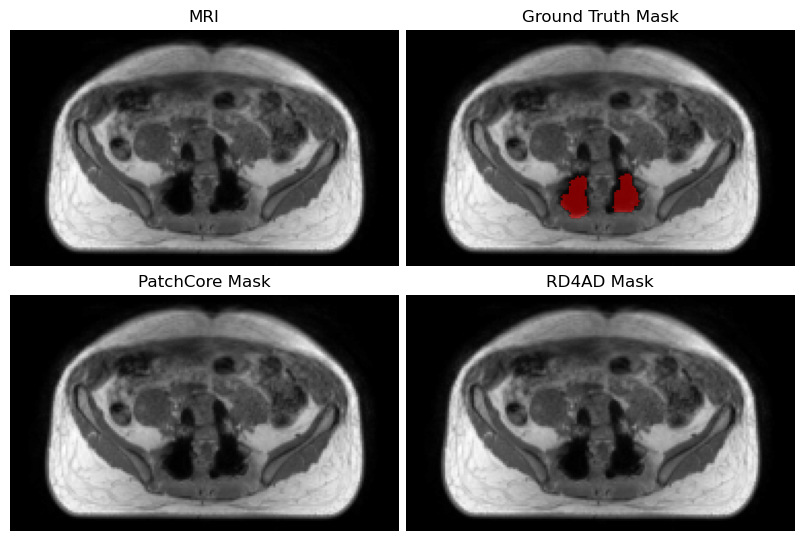

In [39]:
# ---------- load data ----------
mri_vol    = load_nifti_image(mri_path)
gt_mask    = load_nifti_image(gt_path)
pred_rd4ad = load_nifti_image(pred_path_rd4ad)
pred_patch = load_nifti_image(pred_path_patchcore)

gt_bin        = (gt_mask > 0).astype(np.uint8)
pred_rd4ad_b  = (pred_rd4ad > 0).astype(np.uint8)
pred_patch_b  = (pred_patch > 0).astype(np.uint8)

# preprocess MRI to 224x224 (your existing function)
mr_resized = preprocess_mri_to_224_cropped(mri_vol)

slice_idx = 100
mr_slice  = mr_resized[:, :, slice_idx]

# ---- lateral crop from MRI ----
thr = 5
mask_nonzero = mr_slice > thr
cols = np.any(mask_nonzero, axis=0)
col_min, col_max = np.where(cols)[0][[0, -1]]
margin = 5
col_min = max(col_min - margin, 0)
col_max = min(col_max + margin, mr_slice.shape[1] - 1)

mr_crop       = mr_resized[:,      col_min:col_max+1, :]
gt_crop       = gt_bin[:,          col_min:col_max+1, :]
pred_rd4ad_c  = pred_rd4ad_b[:,    col_min:col_max+1, :]
pred_patch_c  = pred_patch_b[:,    col_min:col_max+1, :]

mr_s      = mr_crop[:, :, slice_idx]
gt_s      = gt_crop[:, :, slice_idx].astype(bool)
rd4ad_s   = pred_rd4ad_c[:, :, slice_idx].astype(bool)
patch_s   = pred_patch_c[:, :, slice_idx].astype(bool)

# rotate 90° clockwise
mr_s_r    = np.rot90(mr_s,    k=-1)
gt_s_r    = np.rot90(gt_s,    k=-1)
rd4ad_r   = np.rot90(rd4ad_s, k=-1)
patch_r   = np.rot90(patch_s, k=-1)

# ---- final 10‑pixel crop left & right ----
H, W = mr_s_r.shape
left_crop  = 25
right_crop = 10

mr_s_r  = mr_s_r[:,  left_crop: W - right_crop]
gt_s_r  = gt_s_r[:,  left_crop: W - right_crop]
rd4ad_r = rd4ad_r[:, left_crop: W - right_crop]
patch_r = patch_r[:, left_crop: W - right_crop]

# ---------- plotting: 2x2 (MRI + GT + 2 preds) ----------
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# 1) MRI
axs[0].imshow(mr_s_r, cmap="gray")
axs[0].set_title("MRI")

# 2) GT
axs[1].imshow(mr_s_r, cmap="gray")
overlay_gt = np.zeros((*gt_s_r.shape, 4), dtype=float)
overlay_gt[gt_s_r] = [1.0, 0.0, 0.0, 0.5]
axs[1].imshow(overlay_gt)
axs[1].set_title("Ground Truth Mask")

# 3) Pred model 1 (PatchCore)
axs[2].imshow(mr_s_r, cmap="gray")
overlay_patch = np.zeros((*patch_r.shape, 4), dtype=float)
overlay_patch[patch_r] = [1.0, 0.0, 0.0, 0.5]
axs[2].imshow(overlay_patch)
axs[2].set_title("PatchCore Mask")

# 4) Pred model 2 (RD4AD)
axs[3].imshow(mr_s_r, cmap="gray")
overlay_rd4ad = np.zeros((*rd4ad_r.shape, 4), dtype=float)
overlay_rd4ad[rd4ad_r] = [1.0, 0.0, 0.0, 0.5]
axs[3].imshow(overlay_rd4ad)
axs[3].set_title("RD4AD Mask")

fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.05,
                    wspace=0.02, hspace=0.08)
plt.savefig("figures/mri_gt_pred_overlay_1PA136_110.pdf", bbox_inches="tight")
plt.show()


In [40]:
# Paths (adjust MRI path if needed)
gt_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\Ungood_whole_patient_scans\label\PA152.nii.gz"
pred_path_rd4ad = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\post_processed\Ungood_whole_patient_scans\img\PA152.nii.gz"
pred_path_patchcore = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\Ungood_whole_patient_scans\img\PA152.nii.gz"
mri_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA152\mr.nii.gz"  

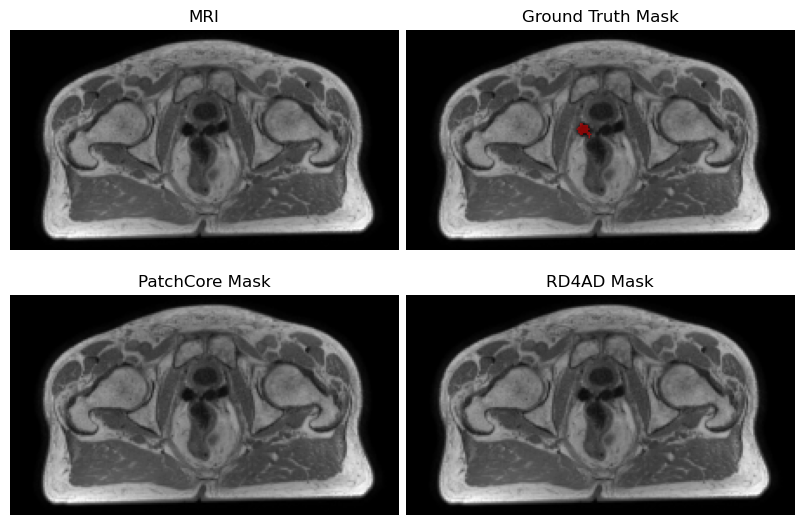

In [41]:
# ---------- load data ----------
mri_vol    = load_nifti_image(mri_path)
gt_mask    = load_nifti_image(gt_path)
pred_rd4ad = load_nifti_image(pred_path_rd4ad)
pred_patch = load_nifti_image(pred_path_patchcore)

gt_bin        = (gt_mask > 0).astype(np.uint8)
pred_rd4ad_b  = (pred_rd4ad > 0).astype(np.uint8)
pred_patch_b  = (pred_patch > 0).astype(np.uint8)

# preprocess MRI to 224x224 (your existing function)
mr_resized = preprocess_mri_to_224_cropped(mri_vol)

slice_idx = 53
mr_slice  = mr_resized[:, :, slice_idx]

# ---- lateral crop from MRI ----
thr = 5
mask_nonzero = mr_slice > thr
cols = np.any(mask_nonzero, axis=0)
col_min, col_max = np.where(cols)[0][[0, -1]]
margin = 5
col_min = max(col_min - margin, 0)
col_max = min(col_max + margin, mr_slice.shape[1] - 1)

mr_crop       = mr_resized[:,      col_min:col_max+1, :]
gt_crop       = gt_bin[:,          col_min:col_max+1, :]
pred_rd4ad_c  = pred_rd4ad_b[:,    col_min:col_max+1, :]
pred_patch_c  = pred_patch_b[:,    col_min:col_max+1, :]

mr_s      = mr_crop[:, :, slice_idx]
gt_s      = gt_crop[:, :, slice_idx].astype(bool)
rd4ad_s   = pred_rd4ad_c[:, :, slice_idx].astype(bool)
patch_s   = pred_patch_c[:, :, slice_idx].astype(bool)

# rotate 90° clockwise
mr_s_r    = np.rot90(mr_s,    k=-1)
gt_s_r    = np.rot90(gt_s,    k=-1)
rd4ad_r   = np.rot90(rd4ad_s, k=-1)
patch_r   = np.rot90(patch_s, k=-1)

# ---------- plotting: 2x2 (MRI + GT + 2 preds) ----------
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# 1) MRI
axs[0].imshow(mr_s_r, cmap="gray")
axs[0].set_title("MRI")

# 2) GT
axs[1].imshow(mr_s_r, cmap="gray")
overlay_gt = np.zeros((*gt_s_r.shape, 4), dtype=float)
overlay_gt[gt_s_r] = [1.0, 0.0, 0.0, 0.5]
axs[1].imshow(overlay_gt)
axs[1].set_title("Ground Truth Mask")

# 3) Pred model 1 (PatchCore)
axs[2].imshow(mr_s_r, cmap="gray")
overlay_patch = np.zeros((*patch_r.shape, 4), dtype=float)
overlay_patch[patch_r] = [1.0, 0.0, 0.0, 0.5]
axs[2].imshow(overlay_patch)
axs[2].set_title("PatchCore Mask")

# 4) Pred model 2 (RD4AD)
axs[3].imshow(mr_s_r, cmap="gray")
overlay_rd4ad = np.zeros((*rd4ad_r.shape, 4), dtype=float)
overlay_rd4ad[rd4ad_r] = [1.0, 0.0, 0.0, 0.5]
axs[3].imshow(overlay_rd4ad)
axs[3].set_title("RD4AD Mask")

fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.05,
                    wspace=0.02, hspace=0.08)
plt.savefig("figures/mri_gt_pred_overlay_1PA152_63.pdf", bbox_inches="tight")
plt.show()


In [79]:
# Paths (adjust MRI path if needed)
gt_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\Ungood_whole_patient_scans\label\PA118.nii.gz"
pred_path_rd4ad = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_patchcore = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_cflow = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_cflow\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_cfa = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_cfa\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_fastflow = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_fastflow\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_stfpm= r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_stfpm\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_draem= r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_draem\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_dinomaly = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_dinomaly\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
mri_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA118\mr.nii.gz"  

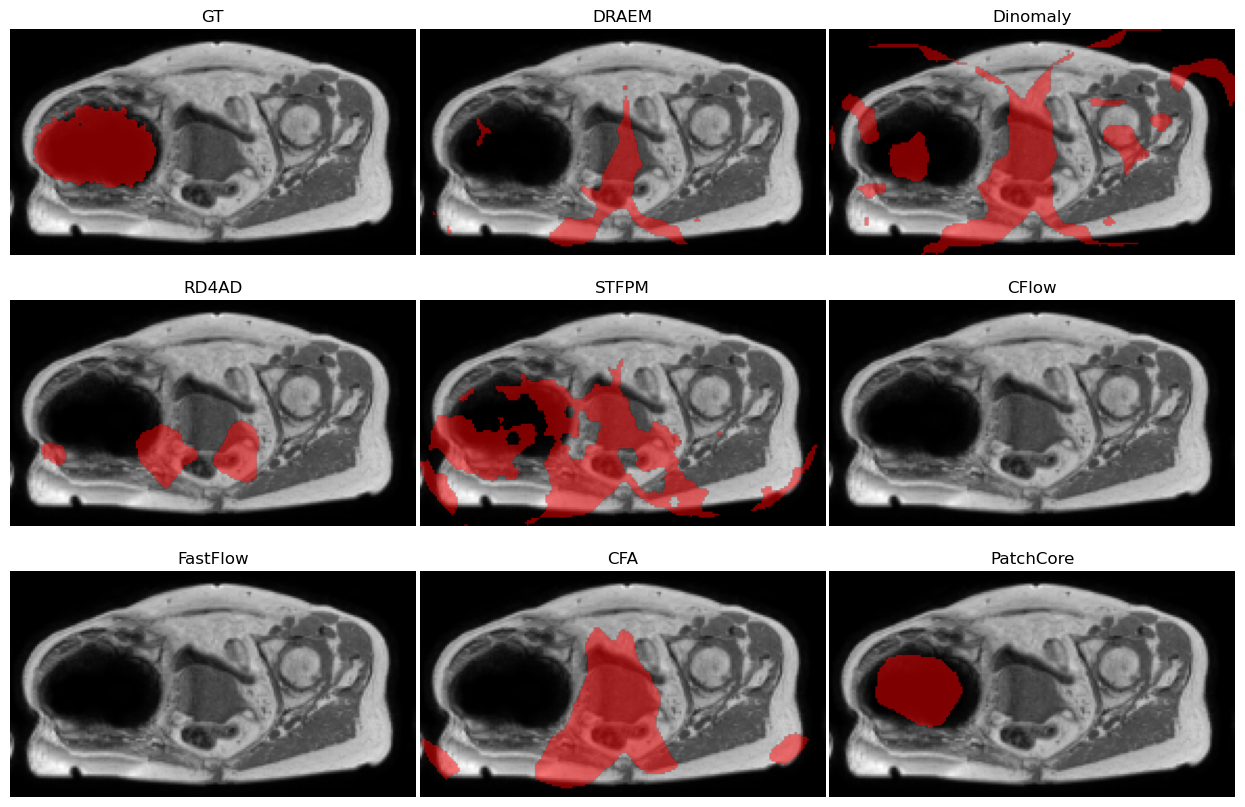

In [82]:
# ---------- load data ----------
mri_vol   = load_nifti_image(mri_path)
gt_mask   = load_nifti_image(gt_path)
pred_rd4ad = load_nifti_image(pred_path_rd4ad)
pred_patch = load_nifti_image(pred_path_patchcore)
pred_cflow = load_nifti_image(pred_path_cflow)
pred_cfa   = load_nifti_image(pred_path_cfa)
pred_fastflow = load_nifti_image(pred_path_fastflow)
pred_stfpm = load_nifti_image(pred_path_stfpm)
pred_draem = load_nifti_image(pred_path_draem)
pred_dinomaly = load_nifti_image(pred_path_dinomaly)

gt_bin       = (gt_mask > 0).astype(np.uint8)
pred_rd4ad_b = (pred_rd4ad > 0).astype(np.uint8)
pred_patch_b = (pred_patch > 0).astype(np.uint8)
pred_cflow_b = (pred_cflow > 0).astype(np.uint8)
pred_cfa_b   = (pred_cfa > 0).astype(np.uint8)
pred_fastflow_b = (pred_fastflow > 0).astype(np.uint8)
pred_stfpm_b = (pred_stfpm > 0).astype(np.uint8)
pred_draem_b = (pred_draem > 0).astype(np.uint8)
pred_dinomaly_b = (pred_dinomaly > 0).astype(np.uint8)

# preprocess MRI (your existing function)
mr_resized = preprocess_mri_to_224_cropped(mri_vol)
assert mr_resized.shape[:2] == gt_bin.shape[:2] == pred_rd4ad_b.shape[:2]

slice_idx = 47
mr_slice = mr_resized[:, :, slice_idx]

# ---- lateral crop from MRI ----
thr = 5
mask_nonzero = mr_slice > thr
cols = np.any(mask_nonzero, axis=0)
col_min, col_max = np.where(cols)[0][[0, -1]]
margin = 5
col_min = max(col_min - margin, 0)
col_max = min(col_max + margin, mr_slice.shape[1] - 1)

mr_crop        = mr_resized[:, col_min:col_max+1, :]
gt_crop        = gt_bin[:, col_min:col_max+1, :]
pred_rd4ad_c   = pred_rd4ad_b[:, col_min:col_max+1, :]
pred_patch_c   = pred_patch_b[:, col_min:col_max+1, :]
pred_cflow_c   = pred_cflow_b[:, col_min:col_max+1, :]
pred_cfa_c     = pred_cfa_b[:, col_min:col_max+1, :]
pred_fastflow_c = pred_fastflow_b[:, col_min:col_max+1, :]
pred_stfpm_c   = pred_stfpm_b[:, col_min:col_max+1, :]
pred_draem_c   = pred_draem_b[:, col_min:col_max+1, :]
pred_dinomaly_c = pred_dinomaly_b[:, col_min:col_max+1, :]

mr_s        = mr_crop[:, :, slice_idx]
gt_s        = gt_crop[:, :, slice_idx].astype(bool)
rd4ad_s     = pred_rd4ad_c[:, :, slice_idx].astype(bool)
patch_s     = pred_patch_c[:, :, slice_idx].astype(bool)
cflow_s     = pred_cflow_c[:, :, slice_idx].astype(bool)
cfa_s       = pred_cfa_c[:, :, slice_idx].astype(bool)
fastflow_s  = pred_fastflow_c[:, :, slice_idx].astype(bool)
stfpm_s     = pred_stfpm_c[:, :, slice_idx].astype(bool)
draem_s     = pred_draem_c[:, :, slice_idx].astype(bool)
dinomaly_s  = pred_dinomaly_c[:, :, slice_idx].astype(bool)

# rotate 90° clockwise
mr_s_r    = np.rot90(mr_s,    k=-1)
gt_s_r    = np.rot90(gt_s,    k=-1)
rd4ad_r   = np.rot90(rd4ad_s, k=-1)
patch_r   = np.rot90(patch_s, k=-1)
cflow_r   = np.rot90(cflow_s, k=-1)
cfa_r     = np.rot90(cfa_s,   k=-1)
fastflow_r = np.rot90(fastflow_s, k=-1)
stfpm_r   = np.rot90(stfpm_s, k=-1)
draem_r   = np.rot90(draem_s, k=-1)
dinomaly_r= np.rot90(dinomaly_s, k=-1)

# ---- final 10‑pixel crop left & right ----
crop = 15
mr_s_r    = mr_s_r[:,    crop:-crop]
gt_s_r    = gt_s_r[:,    crop:-crop]
rd4ad_r   = rd4ad_r[:,   crop:-crop]
patch_r   = patch_r[:,   crop:-crop]
cflow_r   = cflow_r[:,   crop:-crop]
cfa_r     = cfa_r[:,     crop:-crop]
fastflow_r = fastflow_r[:, crop:-crop]
stfpm_r   = stfpm_r[:,   crop:-crop]
draem_r   = draem_r[:,   crop:-crop]
dinomaly_r= dinomaly_r[:, crop:-crop]

# ---------- plotting: 3x3 grid ----------
fig, axs = plt.subplots(3, 3, figsize=(12.5, 9))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# 0) Ground truth
axs[0].imshow(mr_s_r, cmap="gray")
ov_gt = np.zeros((*gt_s_r.shape, 4), dtype=float)
ov_gt[gt_s_r] = [1.0, 0.0, 0.0, 0.5]
axs[0].imshow(ov_gt)
axs[0].set_title("GT")

# 1) DRAEM
axs[1].imshow(mr_s_r, cmap="gray")
ov_dr = np.zeros((*draem_r.shape, 4), dtype=float)
ov_dr[draem_r] = [1.0, 0.0, 0.0, 0.5]
axs[1].imshow(ov_dr)
axs[1].set_title("DRAEM")

# 2) Dinomaly
axs[2].imshow(mr_s_r, cmap="gray")
ov_di = np.zeros((*dinomaly_r.shape, 4), dtype=float)
ov_di[dinomaly_r] = [1.0, 0.0, 0.0, 0.5]
axs[2].imshow(ov_di)
axs[2].set_title("Dinomaly")

# 3) RD4AD
axs[3].imshow(mr_s_r, cmap="gray")
ov_rd = np.zeros((*rd4ad_r.shape, 4), dtype=float)
ov_rd[rd4ad_r] = [1.0, 0.0, 0.0, 0.5]
axs[3].imshow(ov_rd)
axs[3].set_title("RD4AD")

# 4) STFPM
axs[4].imshow(mr_s_r, cmap="gray")
ov_st = np.zeros((*stfpm_r.shape, 4), dtype=float)
ov_st[stfpm_r] = [1.0, 0.0, 0.0, 0.5]
axs[4].imshow(ov_st)
axs[4].set_title("STFPM")

# 5) CFlow
axs[5].imshow(mr_s_r, cmap="gray")
ov_cf = np.zeros((*cflow_r.shape, 4), dtype=float)
ov_cf[cflow_r] = [1.0, 0.0, 0.0, 0.5]
axs[5].imshow(ov_cf)
axs[5].set_title("CFlow")

# 6) FastFlow
axs[6].imshow(mr_s_r, cmap="gray")
ov_ff = np.zeros((*fastflow_r.shape, 4), dtype=float)
ov_ff[fastflow_r] = [1.0, 0.0, 0.0, 0.5]
axs[6].imshow(ov_ff)
axs[6].set_title("FastFlow")

# 7) CFA
axs[7].imshow(mr_s_r, cmap="gray")
ov_cfa = np.zeros((*cfa_r.shape, 4), dtype=float)
ov_cfa[cfa_r] = [1.0, 0.0, 0.0, 0.5]
axs[7].imshow(ov_cfa)
axs[7].set_title("CFA")

# 8) PatchCore
axs[8].imshow(mr_s_r, cmap="gray")
ov_pa = np.zeros((*patch_r.shape, 4), dtype=float)
ov_pa[patch_r] = [1.0, 0.0, 0.0, 0.5]
axs[8].imshow(ov_pa)
axs[8].set_title("PatchCore")


fig.subplots_adjust(
    left=0.01,   # shrink outer margins
    right=0.99,
    top=0.95,
    bottom=0.05,
    wspace=0.01, # horizontal space between subplots
    hspace=0.01  # vertical space between subplots
)
plt.savefig("figures/mri_gt_pred_overlay_1PA118_47.pdf",
            bbox_inches="tight", pad_inches=0.01)
plt.show()



In [102]:
# Paths (adjust MRI path if needed)
gt_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\Ungood_whole_patient_scans\label\PA147.nii.gz"
pred_path_rd4ad = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
pred_path_patchcore = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
pred_path_cflow = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_cflow\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
pred_path_cfa = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_cfa\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
pred_path_fastflow = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_fastflow\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
pred_path_stfpm= r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_stfpm\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
pred_path_draem= r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_draem\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
pred_path_dinomaly = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_dinomaly\post_processed\Ungood_whole_patient_scans\img\PA147.nii.gz"
mri_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA147\mr.nii.gz"  

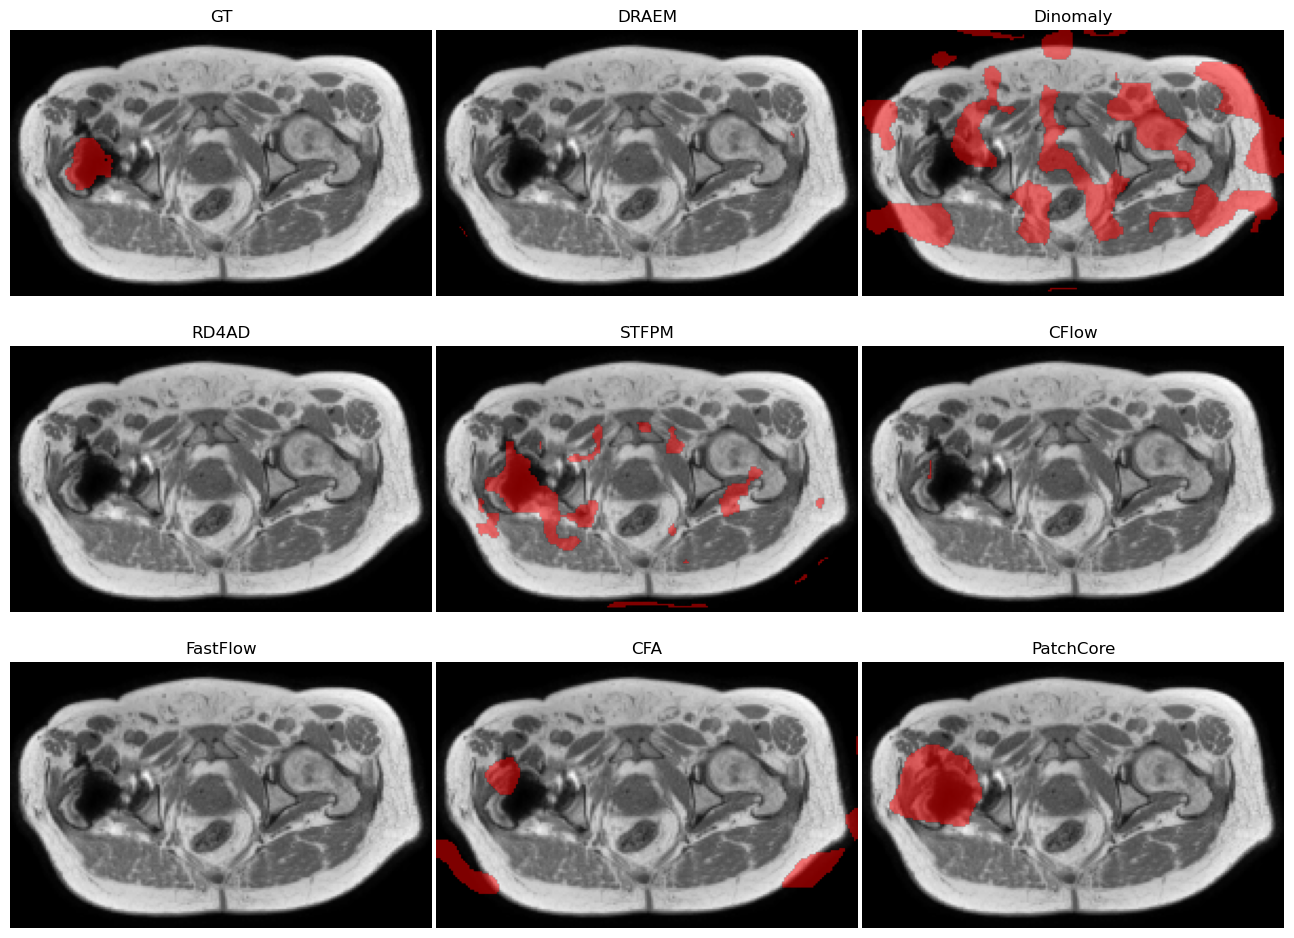

In [111]:
# ---------- load data ----------
mri_vol   = load_nifti_image(mri_path)
gt_mask   = load_nifti_image(gt_path)
pred_rd4ad = load_nifti_image(pred_path_rd4ad)
pred_patch = load_nifti_image(pred_path_patchcore)
pred_cflow = load_nifti_image(pred_path_cflow)
pred_cfa   = load_nifti_image(pred_path_cfa)
pred_fastflow = load_nifti_image(pred_path_fastflow)
pred_stfpm = load_nifti_image(pred_path_stfpm)
pred_draem = load_nifti_image(pred_path_draem)
pred_dinomaly = load_nifti_image(pred_path_dinomaly)

gt_bin       = (gt_mask > 0).astype(np.uint8)
pred_rd4ad_b = (pred_rd4ad > 0).astype(np.uint8)
pred_patch_b = (pred_patch > 0).astype(np.uint8)
pred_cflow_b = (pred_cflow > 0).astype(np.uint8)
pred_cfa_b   = (pred_cfa > 0).astype(np.uint8)
pred_fastflow_b = (pred_fastflow > 0).astype(np.uint8)
pred_stfpm_b = (pred_stfpm > 0).astype(np.uint8)
pred_draem_b = (pred_draem > 0).astype(np.uint8)
pred_dinomaly_b = (pred_dinomaly > 0).astype(np.uint8)

# preprocess MRI (your existing function)
mr_resized = preprocess_mri_to_224_cropped(mri_vol)
assert mr_resized.shape[:2] == gt_bin.shape[:2] == pred_rd4ad_b.shape[:2]

slice_idx = 41
mr_slice = mr_resized[:, :, slice_idx]

# ---- lateral crop from MRI ----
thr = 5
mask_nonzero = mr_slice > thr
cols = np.any(mask_nonzero, axis=0)
col_min, col_max = np.where(cols)[0][[0, -1]]
margin = 5
col_min = max(col_min - margin, 0)
col_max = min(col_max + margin, mr_slice.shape[1] - 1)

mr_crop        = mr_resized[:, col_min:col_max+1, :]
gt_crop        = gt_bin[:, col_min:col_max+1, :]
pred_rd4ad_c   = pred_rd4ad_b[:, col_min:col_max+1, :]
pred_patch_c   = pred_patch_b[:, col_min:col_max+1, :]
pred_cflow_c   = pred_cflow_b[:, col_min:col_max+1, :]
pred_cfa_c     = pred_cfa_b[:, col_min:col_max+1, :]
pred_fastflow_c = pred_fastflow_b[:, col_min:col_max+1, :]
pred_stfpm_c   = pred_stfpm_b[:, col_min:col_max+1, :]
pred_draem_c   = pred_draem_b[:, col_min:col_max+1, :]
pred_dinomaly_c = pred_dinomaly_b[:, col_min:col_max+1, :]

mr_s        = mr_crop[:, :, slice_idx]
gt_s        = gt_crop[:, :, slice_idx].astype(bool)
rd4ad_s     = pred_rd4ad_c[:, :, slice_idx].astype(bool)
patch_s     = pred_patch_c[:, :, slice_idx].astype(bool)
cflow_s     = pred_cflow_c[:, :, slice_idx].astype(bool)
cfa_s       = pred_cfa_c[:, :, slice_idx].astype(bool)
fastflow_s  = pred_fastflow_c[:, :, slice_idx].astype(bool)
stfpm_s     = pred_stfpm_c[:, :, slice_idx].astype(bool)
draem_s     = pred_draem_c[:, :, slice_idx].astype(bool)
dinomaly_s  = pred_dinomaly_c[:, :, slice_idx].astype(bool)

# rotate 90° clockwise
mr_s_r    = np.rot90(mr_s,    k=-1)
gt_s_r    = np.rot90(gt_s,    k=-1)
rd4ad_r   = np.rot90(rd4ad_s, k=-1)
patch_r   = np.rot90(patch_s, k=-1)
cflow_r   = np.rot90(cflow_s, k=-1)
cfa_r     = np.rot90(cfa_s,   k=-1)
fastflow_r = np.rot90(fastflow_s, k=-1)
stfpm_r   = np.rot90(stfpm_s, k=-1)
draem_r   = np.rot90(draem_s, k=-1)
dinomaly_r= np.rot90(dinomaly_s, k=-1)

# ---- final 10‑pixel crop left & right ----
crop = 12
mr_s_r    = mr_s_r[:,    crop:-crop]
gt_s_r    = gt_s_r[:,    crop:-crop]
rd4ad_r   = rd4ad_r[:,   crop:-crop]
patch_r   = patch_r[:,   crop:-crop]
cflow_r   = cflow_r[:,   crop:-crop]
cfa_r     = cfa_r[:,     crop:-crop]
fastflow_r = fastflow_r[:, crop:-crop]
stfpm_r   = stfpm_r[:,   crop:-crop]
draem_r   = draem_r[:,   crop:-crop]
dinomaly_r= dinomaly_r[:, crop:-crop]

# ---------- plotting: 3x3 grid ----------
fig, axs = plt.subplots(3, 3, figsize=(13, 10.5))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# 0) Ground truth
axs[0].imshow(mr_s_r, cmap="gray")
ov_gt = np.zeros((*gt_s_r.shape, 4), dtype=float)
ov_gt[gt_s_r] = [1.0, 0.0, 0.0, 0.5]
axs[0].imshow(ov_gt)
axs[0].set_title("GT")

# 1) DRAEM
axs[1].imshow(mr_s_r, cmap="gray")
ov_dr = np.zeros((*draem_r.shape, 4), dtype=float)
ov_dr[draem_r] = [1.0, 0.0, 0.0, 0.5]
axs[1].imshow(ov_dr)
axs[1].set_title("DRAEM")

# 2) Dinomaly
axs[2].imshow(mr_s_r, cmap="gray")
ov_di = np.zeros((*dinomaly_r.shape, 4), dtype=float)
ov_di[dinomaly_r] = [1.0, 0.0, 0.0, 0.5]
axs[2].imshow(ov_di)
axs[2].set_title("Dinomaly")

# 3) RD4AD
axs[3].imshow(mr_s_r, cmap="gray")
ov_rd = np.zeros((*rd4ad_r.shape, 4), dtype=float)
ov_rd[rd4ad_r] = [1.0, 0.0, 0.0, 0.5]
axs[3].imshow(ov_rd)
axs[3].set_title("RD4AD")

# 4) STFPM
axs[4].imshow(mr_s_r, cmap="gray")
ov_st = np.zeros((*stfpm_r.shape, 4), dtype=float)
ov_st[stfpm_r] = [1.0, 0.0, 0.0, 0.5]
axs[4].imshow(ov_st)
axs[4].set_title("STFPM")

# 5) CFlow
axs[5].imshow(mr_s_r, cmap="gray")
ov_cf = np.zeros((*cflow_r.shape, 4), dtype=float)
ov_cf[cflow_r] = [1.0, 0.0, 0.0, 0.5]
axs[5].imshow(ov_cf)
axs[5].set_title("CFlow")

# 6) FastFlow
axs[6].imshow(mr_s_r, cmap="gray")
ov_ff = np.zeros((*fastflow_r.shape, 4), dtype=float)
ov_ff[fastflow_r] = [1.0, 0.0, 0.0, 0.5]
axs[6].imshow(ov_ff)
axs[6].set_title("FastFlow")

# 7) CFA
axs[7].imshow(mr_s_r, cmap="gray")
ov_cfa = np.zeros((*cfa_r.shape, 4), dtype=float)
ov_cfa[cfa_r] = [1.0, 0.0, 0.0, 0.5]
axs[7].imshow(ov_cfa)
axs[7].set_title("CFA")

# 8) PatchCore
axs[8].imshow(mr_s_r, cmap="gray")
ov_pa = np.zeros((*patch_r.shape, 4), dtype=float)
ov_pa[patch_r] = [1.0, 0.0, 0.0, 0.5]
axs[8].imshow(ov_pa)
axs[8].set_title("PatchCore")


fig.subplots_adjust(
    left=0.01,   # shrink outer margins
    right=0.99,
    top=0.95,
    bottom=0.05,
    wspace=0.01, # horizontal space between subplots
    hspace=0.01  # vertical space between subplots
)
plt.savefig("figures/mri_gt_pred_overlay_1PA147_51.pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()



In [91]:
# Paths (adjust MRI path if needed)
gt_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\good\label\PA058.nii.gz"
pred_path_rd4ad = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\post_processed\good\img\PA058.nii.gz"
pred_path_patchcore = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\good\img\PA058.nii.gz"
pred_path_cflow = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_cflow\post_processed\good\img\PA058.nii.gz"
pred_path_cfa = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_cfa\post_processed\good\img\PA058.nii.gz"
pred_path_fastflow = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_fastflow\post_processed\good\img\PA058.nii.gz"
pred_path_stfpm= r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_stfpm\post_processed\good\img\PA058.nii.gz"
pred_path_draem= r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_draem\post_processed\good\img\PA058.nii.gz"
pred_path_dinomaly = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp1_dinomaly\post_processed\good\img\PA058.nii.gz"
mri_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA058\mr.nii.gz"  

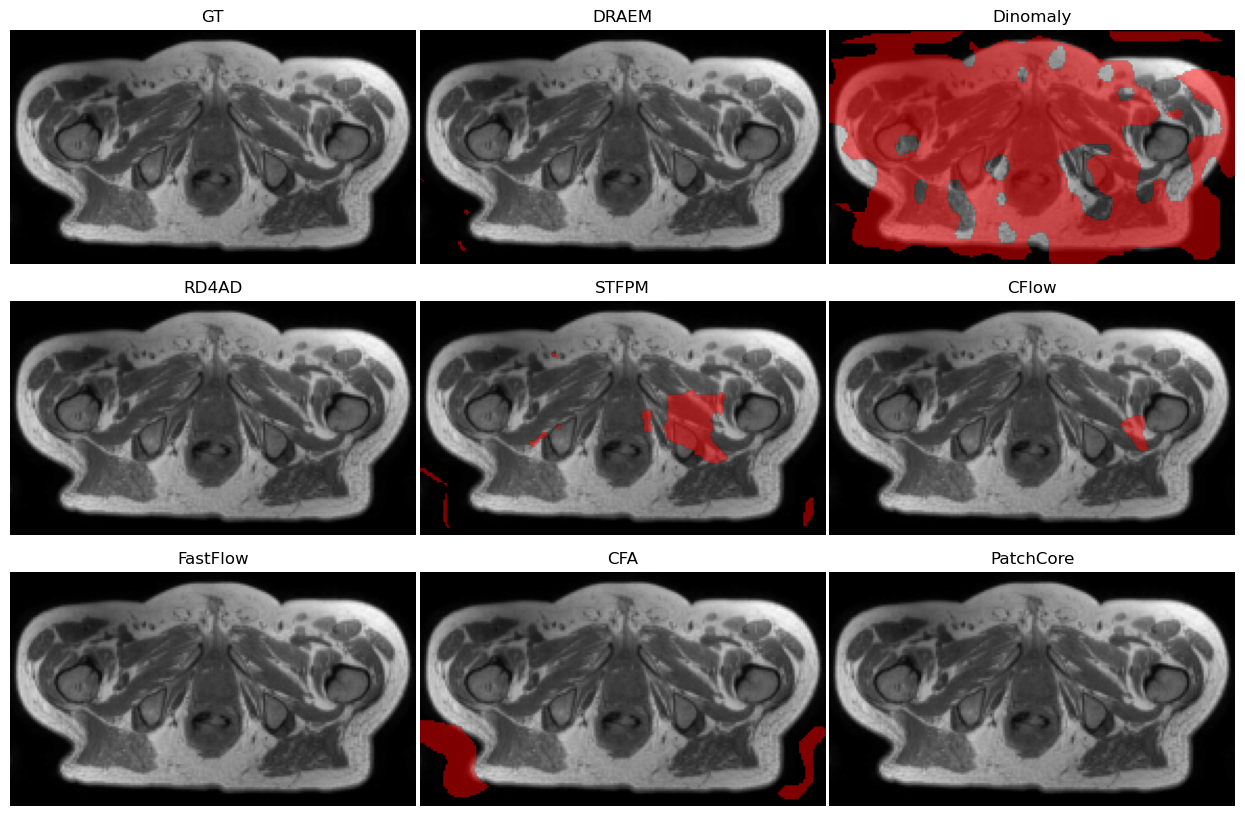

In [92]:
mri_vol   = load_nifti_image(mri_path)
gt_mask   = load_nifti_image(gt_path)
pred_rd4ad = load_nifti_image(pred_path_rd4ad)
pred_patch = load_nifti_image(pred_path_patchcore)
pred_cflow = load_nifti_image(pred_path_cflow)
pred_cfa   = load_nifti_image(pred_path_cfa)
pred_fastflow = load_nifti_image(pred_path_fastflow)
pred_stfpm = load_nifti_image(pred_path_stfpm)
pred_draem = load_nifti_image(pred_path_draem)
pred_dinomaly = load_nifti_image(pred_path_dinomaly)

gt_bin       = (gt_mask > 0).astype(np.uint8)
pred_rd4ad_b = (pred_rd4ad > 0).astype(np.uint8)
pred_patch_b = (pred_patch > 0).astype(np.uint8)
pred_cflow_b = (pred_cflow > 0).astype(np.uint8)
pred_cfa_b   = (pred_cfa > 0).astype(np.uint8)
pred_fastflow_b = (pred_fastflow > 0).astype(np.uint8)
pred_stfpm_b = (pred_stfpm > 0).astype(np.uint8)
pred_draem_b = (pred_draem > 0).astype(np.uint8)
pred_dinomaly_b = (pred_dinomaly > 0).astype(np.uint8)

# preprocess MRI (your existing function)
mr_resized = preprocess_mri_to_224_cropped(mri_vol)
assert mr_resized.shape[:2] == gt_bin.shape[:2] == pred_rd4ad_b.shape[:2]

slice_idx = 35
mr_slice = mr_resized[:, :, slice_idx]

# ---- lateral crop from MRI ----
thr = 5
mask_nonzero = mr_slice > thr
cols = np.any(mask_nonzero, axis=0)
col_min, col_max = np.where(cols)[0][[0, -1]]
margin = 5
col_min = max(col_min - margin, 0)
col_max = min(col_max + margin, mr_slice.shape[1] - 1)

mr_crop        = mr_resized[:, col_min:col_max+1, :]
gt_crop        = gt_bin[:, col_min:col_max+1, :]
pred_rd4ad_c   = pred_rd4ad_b[:, col_min:col_max+1, :]
pred_patch_c   = pred_patch_b[:, col_min:col_max+1, :]
pred_cflow_c   = pred_cflow_b[:, col_min:col_max+1, :]
pred_cfa_c     = pred_cfa_b[:, col_min:col_max+1, :]
pred_fastflow_c = pred_fastflow_b[:, col_min:col_max+1, :]
pred_stfpm_c   = pred_stfpm_b[:, col_min:col_max+1, :]
pred_draem_c   = pred_draem_b[:, col_min:col_max+1, :]
pred_dinomaly_c = pred_dinomaly_b[:, col_min:col_max+1, :]

mr_s        = mr_crop[:, :, slice_idx]
gt_s        = gt_crop[:, :, slice_idx].astype(bool)
rd4ad_s     = pred_rd4ad_c[:, :, slice_idx].astype(bool)
patch_s     = pred_patch_c[:, :, slice_idx].astype(bool)
cflow_s     = pred_cflow_c[:, :, slice_idx].astype(bool)
cfa_s       = pred_cfa_c[:, :, slice_idx].astype(bool)
fastflow_s  = pred_fastflow_c[:, :, slice_idx].astype(bool)
stfpm_s     = pred_stfpm_c[:, :, slice_idx].astype(bool)
draem_s     = pred_draem_c[:, :, slice_idx].astype(bool)
dinomaly_s  = pred_dinomaly_c[:, :, slice_idx].astype(bool)

# rotate 90° clockwise
mr_s_r    = np.rot90(mr_s,    k=-1)
gt_s_r    = np.rot90(gt_s,    k=-1)
rd4ad_r   = np.rot90(rd4ad_s, k=-1)
patch_r   = np.rot90(patch_s, k=-1)
cflow_r   = np.rot90(cflow_s, k=-1)
cfa_r     = np.rot90(cfa_s,   k=-1)
fastflow_r = np.rot90(fastflow_s, k=-1)
stfpm_r   = np.rot90(stfpm_s, k=-1)
draem_r   = np.rot90(draem_s, k=-1)
dinomaly_r= np.rot90(dinomaly_s, k=-1)

# ---- final 10‑pixel crop left & right ----
crop = 15
mr_s_r    = mr_s_r[:,    crop:-crop]
gt_s_r    = gt_s_r[:,    crop:-crop]
rd4ad_r   = rd4ad_r[:,   crop:-crop]
patch_r   = patch_r[:,   crop:-crop]
cflow_r   = cflow_r[:,   crop:-crop]
cfa_r     = cfa_r[:,     crop:-crop]
fastflow_r = fastflow_r[:, crop:-crop]
stfpm_r   = stfpm_r[:,   crop:-crop]
draem_r   = draem_r[:,   crop:-crop]
dinomaly_r= dinomaly_r[:, crop:-crop]

# ---------- plotting: 3x3 grid ----------
fig, axs = plt.subplots(3, 3, figsize=(12.5, 9))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# 0) Ground truth
axs[0].imshow(mr_s_r, cmap="gray")
ov_gt = np.zeros((*gt_s_r.shape, 4), dtype=float)
ov_gt[gt_s_r] = [1.0, 0.0, 0.0, 0.5]
axs[0].imshow(ov_gt)
axs[0].set_title("GT")

# 1) DRAEM
axs[1].imshow(mr_s_r, cmap="gray")
ov_dr = np.zeros((*draem_r.shape, 4), dtype=float)
ov_dr[draem_r] = [1.0, 0.0, 0.0, 0.5]
axs[1].imshow(ov_dr)
axs[1].set_title("DRAEM")

# 2) Dinomaly
axs[2].imshow(mr_s_r, cmap="gray")
ov_di = np.zeros((*dinomaly_r.shape, 4), dtype=float)
ov_di[dinomaly_r] = [1.0, 0.0, 0.0, 0.5]
axs[2].imshow(ov_di)
axs[2].set_title("Dinomaly")

# 3) RD4AD
axs[3].imshow(mr_s_r, cmap="gray")
ov_rd = np.zeros((*rd4ad_r.shape, 4), dtype=float)
ov_rd[rd4ad_r] = [1.0, 0.0, 0.0, 0.5]
axs[3].imshow(ov_rd)
axs[3].set_title("RD4AD")

# 4) STFPM
axs[4].imshow(mr_s_r, cmap="gray")
ov_st = np.zeros((*stfpm_r.shape, 4), dtype=float)
ov_st[stfpm_r] = [1.0, 0.0, 0.0, 0.5]
axs[4].imshow(ov_st)
axs[4].set_title("STFPM")

# 5) CFlow
axs[5].imshow(mr_s_r, cmap="gray")
ov_cf = np.zeros((*cflow_r.shape, 4), dtype=float)
ov_cf[cflow_r] = [1.0, 0.0, 0.0, 0.5]
axs[5].imshow(ov_cf)
axs[5].set_title("CFlow")

# 6) FastFlow
axs[6].imshow(mr_s_r, cmap="gray")
ov_ff = np.zeros((*fastflow_r.shape, 4), dtype=float)
ov_ff[fastflow_r] = [1.0, 0.0, 0.0, 0.5]
axs[6].imshow(ov_ff)
axs[6].set_title("FastFlow")

# 7) CFA
axs[7].imshow(mr_s_r, cmap="gray")
ov_cfa = np.zeros((*cfa_r.shape, 4), dtype=float)
ov_cfa[cfa_r] = [1.0, 0.0, 0.0, 0.5]
axs[7].imshow(ov_cfa)
axs[7].set_title("CFA")

# 8) PatchCore
axs[8].imshow(mr_s_r, cmap="gray")
ov_pa = np.zeros((*patch_r.shape, 4), dtype=float)
ov_pa[patch_r] = [1.0, 0.0, 0.0, 0.5]
axs[8].imshow(ov_pa)
axs[8].set_title("PatchCore")

fig.subplots_adjust(
    left=0.01,   # shrink outer margins
    right=0.99,
    top=0.95,
    bottom=0.05,
    wspace=0.01, # horizontal space between subplots
    hspace=0.01  # vertical space between subplots
)
plt.savefig("figures/mri_gt_pred_overlay_1PA058_35.pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()


In [63]:
def preprocess_for_vis(mri_path, gt_path, pred_path_rep, pred_path_con, pred_path_color, slice_idx, crop=15, margin=5):
    # ---------- load data ----------
    mri_vol   = load_nifti_image(mri_path)
    gt_mask   = load_nifti_image(gt_path)
    pred_rep = load_nifti_image(pred_path_rep)
    pred_con = load_nifti_image(pred_path_con)
    pred_color = load_nifti_image(pred_path_color)

    gt_bin       = (gt_mask > 0).astype(np.uint8)
    pred_rep_b = (pred_rep > 0).astype(np.uint8)
    pred_con_b = (pred_con > 0).astype(np.uint8)
    pred_color_b = (pred_color > 0).astype(np.uint8)

    # preprocess MRI (your existing function)
    mr_resized = preprocess_mri_to_224_cropped(mri_vol)
    assert mr_resized.shape[:2] == gt_bin.shape[:2] == pred_rep_b.shape[:2]

    mr_slice = mr_resized[:, :, slice_idx]

    # ---- lateral crop from MRI ----
    thr = 5
    mask_nonzero = mr_slice > thr
    cols = np.any(mask_nonzero, axis=0)
    col_min, col_max = np.where(cols)[0][[0, -1]]

    col_min = max(col_min - margin, 0)
    col_max = min(col_max + margin, mr_slice.shape[1] - 1)

    mr_crop        = mr_resized[:, col_min:col_max+1, :]
    gt_crop        = gt_bin[:, col_min:col_max+1, :]
    pred_rep_c   = pred_rep_b[:, col_min:col_max+1, :]
    pred_con_c   = pred_con_b[:, col_min:col_max+1, :]
    pred_color_c   = pred_color_b[:, col_min:col_max+1, :]

    mr_s        = mr_crop[:, :, slice_idx]
    gt_s        = gt_crop[:, :, slice_idx].astype(bool)
    rep_s     = pred_rep_c[:, :, slice_idx].astype(bool)
    con_s     = pred_con_c[:, :, slice_idx].astype(bool)
    color_s     = pred_color_c[:, :, slice_idx].astype(bool)

    # rotate 90° clockwise
    mr_s_r    = np.rot90(mr_s,    k=-1)
    gt_s_r    = np.rot90(gt_s,    k=-1)
    rep_r   = np.rot90(rep_s, k=-1)
    con_r   = np.rot90(con_s, k=-1)
    color_r   = np.rot90(color_s, k=-1)

    mr_s_r    = mr_s_r[:,    crop:-crop]
    gt_s_r    = gt_s_r[:,    crop:-crop]
    rep_r   = rep_r[:,   crop:-crop]
    con_r   = con_r[:,   crop:-crop]
    color_r   = color_r[:,   crop:-crop]

    return mr_s_r, gt_s_r, rep_r, con_r, color_r

In [76]:
# Paths 
gt_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\Ungood_whole_patient_scans\label\PA118.nii.gz"
pred_path_rep = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_con = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore_con\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_color = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore_png\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
mri_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA118\mr.nii.gz"

# Paths 155
gt_path_2 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\Ungood_whole_patient_scans\label\PA155.nii.gz"
pred_path_rep_2 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\Ungood_whole_patient_scans\img\PA155.nii.gz"
pred_path_con_2 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore_con\post_processed\Ungood_whole_patient_scans\img\PA155.nii.gz"
pred_path_color_2 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore_png\post_processed\Ungood_whole_patient_scans\img\PA155.nii.gz"      
mri_path_2 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA155\mr.nii.gz"

# Paths 169
gt_path_3 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_rep_lr_0001\ground_truth\Ungood_whole_patient_scans\label\PA169.nii.gz"
pred_path_rep_3 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore\post_processed\Ungood_whole_patient_scans\img\PA169.nii.gz"
pred_path_con_3 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore_con\post_processed\Ungood_whole_patient_scans\img\PA169.nii.gz"
pred_path_color_3 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\volumes_v7_patchcore_png\post_processed\Ungood_whole_patient_scans\img\PA169.nii.gz"      
mri_path_3 = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA169\mr.nii.gz"


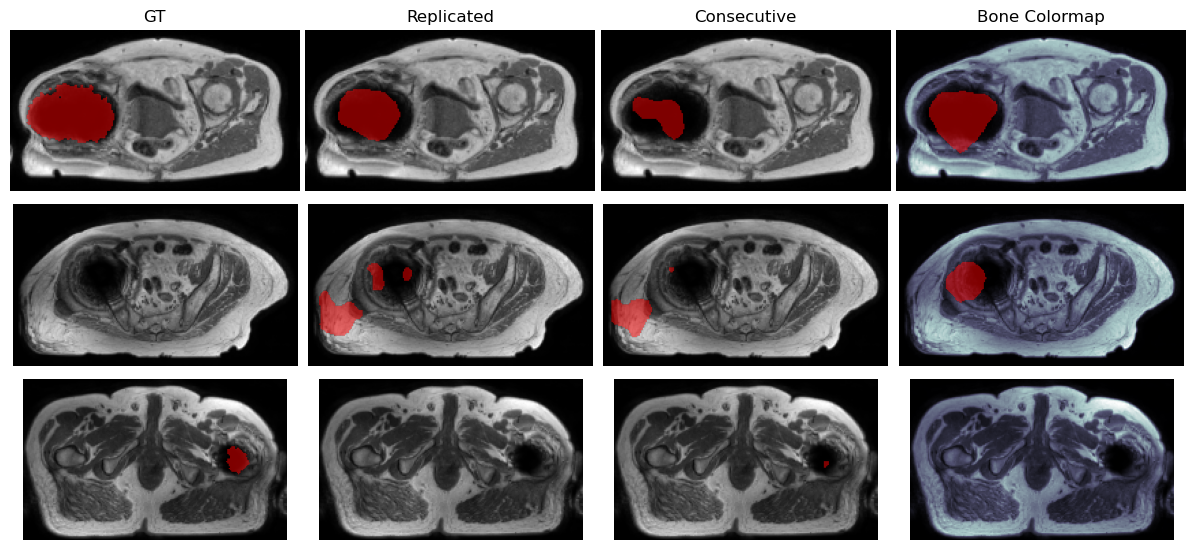

In [80]:
mr_s_r, gt_s_r, rep_r, con_r, color_r = preprocess_for_vis(
    mri_path, gt_path, pred_path_rep, pred_path_con, pred_path_color, slice_idx=47
)


fig, axs = plt.subplots(3, 4, figsize=(12, 6))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")

# 1) Ground truth
axs[0].imshow(mr_s_r, cmap="gray")
ov_gt = np.zeros((*gt_s_r.shape, 4), dtype=float)
ov_gt[gt_s_r] = [1.0, 0.0, 0.0, 0.5]
axs[0].imshow(ov_gt)
axs[0].set_title("GT")


# 2) Replicated
axs[1].imshow(mr_s_r, cmap="gray")
ov_rd = np.zeros((*rep_r.shape, 4), dtype=float)
ov_rd[rep_r] = [1.0, 0.0, 0.0, 0.5]
axs[1].imshow(ov_rd)
axs[1].set_title("Replicated")

# 3) Consectuive
axs[2].imshow(mr_s_r, cmap="gray")
ov_pa = np.zeros((*con_r.shape, 4), dtype=float)
ov_pa[con_r] = [1.0, 0.0, 0.0, 0.5]
axs[2].imshow(ov_pa)
axs[2].set_title("Consecutive")

# 4) Colormap
axs[3].imshow(mr_s_r, cmap="bone")
ov_cf = np.zeros((*color_r.shape, 4), dtype=float)
ov_cf[color_r] = [1.0, 0.0, 0.0, 0.5]
axs[3].imshow(ov_cf)
axs[3].set_title("Bone Colormap")

mr_s_r_2, gt_s_r_2, rep_r_2, con_r_2, color_r_2 = preprocess_for_vis(
    mri_path_2, gt_path_2, pred_path_rep_2, pred_path_con_2, pred_path_color_2, slice_idx=92, crop=8
)

# 5) Ground truth
axs[4].imshow(mr_s_r_2, cmap="gray")
ov_gt_2 = np.zeros((*gt_s_r_2.shape, 4), dtype=float)
ov_gt_2[gt_s_r_2] = [1.0, 0.0, 0.0, 0.5]
axs[4].imshow(ov_gt_2)


# 6) Replicated
axs[5].imshow(mr_s_r_2, cmap="gray")
ov_rd_2 = np.zeros((*rep_r_2.shape, 4), dtype=float)
ov_rd_2[rep_r_2] = [1.0, 0.0, 0.0, 0.5]
axs[5].imshow(ov_rd_2)


# 7) Consectuive
axs[6].imshow(mr_s_r_2, cmap="gray")
ov_pa_2 = np.zeros((*con_r_2.shape, 4), dtype=float)
ov_pa_2[con_r_2] = [1.0, 0.0, 0.0, 0.5]
axs[6].imshow(ov_pa_2)

# 8) Colormap
axs[7].imshow(mr_s_r_2, cmap="bone")
ov_cf_2 = np.zeros((*color_r_2.shape, 4), dtype=float)
ov_cf_2[color_r_2] = [1.0, 0.0, 0.0, 0.5]
axs[7].imshow(ov_cf_2)


mr_s_r_3, gt_s_r_3, rep_r_3, con_r_3, color_r_3 = preprocess_for_vis(
    mri_path_3, gt_path_3, pred_path_rep_3, pred_path_con_3, pred_path_color_3, slice_idx=45, crop=15, margin=0
)

# 9) Ground truth
axs[8].imshow(mr_s_r_3, cmap="gray")
ov_gt_3 = np.zeros((*gt_s_r_3.shape, 4), dtype=float)
ov_gt_3[gt_s_r_3] = [1.0, 0.0, 0.0, 0.5]
axs[8].imshow(ov_gt_3)

# 10) Replicated
axs[9].imshow(mr_s_r_3, cmap="gray")
ov_rd_3 = np.zeros((*rep_r_3.shape, 4), dtype=float)
ov_rd_3[rep_r_3] = [1.0, 0.0, 0.0, 0.5]
axs[9].imshow(ov_rd_3)


# 11) Consectuive
axs[10].imshow(mr_s_r_3, cmap="gray")
ov_pa_3 = np.zeros((*con_r_3.shape, 4), dtype=float)
ov_pa_3[con_r_3] = [1.0, 0.0, 0.0, 0.5]
axs[10].imshow(ov_pa_3)

# 12) Colormap
axs[11].imshow(mr_s_r_3, cmap="bone")
ov_cf_3 = np.zeros((*color_r_3.shape, 4), dtype=float)
ov_cf_3[color_r_3] = [1.0, 0.0, 0.0, 0.5]
axs[11].imshow(ov_cf_3)


fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.05, wspace=0.02, hspace=0.08)
plt.savefig("figures/exp2_patchcore_vis.pdf", bbox_inches="tight")
plt.show()




In [94]:
# Paths 
gt_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp3_fastflow_rep\ground_truth\Ungood_whole_patient_scans\label\PA118.nii.gz"
pred_path_rep = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp3_fastflow_rep\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_con = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp3_fastflow_con\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
pred_path_color = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\exp3_fastflow_png\post_processed\Ungood_whole_patient_scans\img\PA118.nii.gz"
mri_path = r"C:\Users\justi\OneDrive\Desktop\University\Master_Studium\MP\code\test_preprocessing\data\Task1\1PA118\mr.nii.gz"

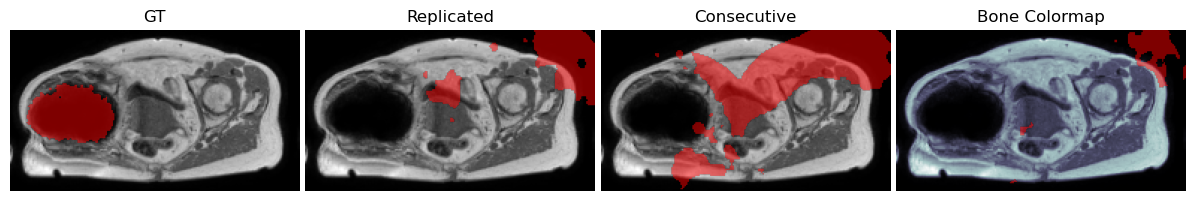

In [98]:
# ---------- load data ----------
mri_vol   = load_nifti_image(mri_path)
gt_mask   = load_nifti_image(gt_path)
pred_rep = load_nifti_image(pred_path_rep)
pred_con = load_nifti_image(pred_path_con)
pred_color = load_nifti_image(pred_path_color)

gt_bin       = (gt_mask > 0).astype(np.uint8)
pred_rep_b = (pred_rep > 0).astype(np.uint8)
pred_con_b = (pred_con > 0).astype(np.uint8)
pred_color_b = (pred_color > 0).astype(np.uint8)

# preprocess MRI (your existing function)
mr_resized = preprocess_mri_to_224_cropped(mri_vol)
assert mr_resized.shape[:2] == gt_bin.shape[:2] == pred_rep_b.shape[:2]

slice_idx = 47
mr_slice = mr_resized[:, :, slice_idx]

# ---- lateral crop from MRI ----
thr = 5
mask_nonzero = mr_slice > thr
cols = np.any(mask_nonzero, axis=0)
col_min, col_max = np.where(cols)[0][[0, -1]]
margin = 5
col_min = max(col_min - margin, 0)
col_max = min(col_max + margin, mr_slice.shape[1] - 1)

mr_crop        = mr_resized[:, col_min:col_max+1, :]
gt_crop        = gt_bin[:, col_min:col_max+1, :]
pred_rep_c   = pred_rep_b[:, col_min:col_max+1, :]
pred_con_c   = pred_con_b[:, col_min:col_max+1, :]
pred_color_c   = pred_color_b[:, col_min:col_max+1, :]

mr_s        = mr_crop[:, :, slice_idx]
gt_s        = gt_crop[:, :, slice_idx].astype(bool)
rep_s     = pred_rep_c[:, :, slice_idx].astype(bool)
con_s     = pred_con_c[:, :, slice_idx].astype(bool)
color_s     = pred_color_c[:, :, slice_idx].astype(bool)

# rotate 90° clockwise
mr_s_r    = np.rot90(mr_s,    k=-1)
gt_s_r    = np.rot90(gt_s,    k=-1)
rep_r   = np.rot90(rep_s, k=-1)
con_r   = np.rot90(con_s, k=-1)
color_r   = np.rot90(color_s, k=-1)

crop = 15
mr_s_r    = mr_s_r[:,    crop:-crop]
gt_s_r    = gt_s_r[:,    crop:-crop]
rep_r   = rep_r[:,   crop:-crop]
con_r   = con_r[:,   crop:-crop]
color_r   = color_r[:,   crop:-crop]

fig, axs = plt.subplots(1, 4, figsize=(12, 6))
axs = axs.ravel()
for ax in axs:
    ax.axis("off")


# 1) Ground truth
axs[0].imshow(mr_s_r, cmap="gray")
ov_gt = np.zeros((*gt_s_r.shape, 4), dtype=float)
ov_gt[gt_s_r] = [1.0, 0.0, 0.0, 0.5]
axs[0].imshow(ov_gt)
axs[0].set_title("GT")      
# 2) RD4AD
axs[1].imshow(mr_s_r, cmap="gray")
ov_rd = np.zeros((*rep_r.shape, 4), dtype=float)
ov_rd[rep_r] = [1.0, 0.0, 0.0, 0.5]
axs[1].imshow(ov_rd)
axs[1].set_title("Replicated")
# 3) PatchCore
axs[2].imshow(mr_s_r, cmap="gray")
ov_pa = np.zeros((*con_r.shape, 4), dtype=float)
ov_pa[con_r] = [1.0, 0.0, 0.0, 0.5]
axs[2].imshow(ov_pa)
axs[2].set_title("Consecutive")
# 4) CFlow
axs[3].imshow(mr_s_r, cmap="bone")
ov_cf = np.zeros((*color_r.shape, 4), dtype=float)
ov_cf[color_r] = [1.0, 0.0, 0.0, 0.5]
axs[3].imshow(ov_cf)
axs[3].set_title("Bone Colormap")

fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.05, wspace=0.02, hspace=0.08)
plt.savefig("figures/exp3_overlay_1PA118_47.pdf", bbox_inches="tight")
plt.show()
